# Part 2: Dynestyx — NumPyro with better support for dynamical systems
We introduce **dynestyx** as an extension of NumPyro for **dynamical systems**, with a clear separation between *what* the model is and *how* we simulate or score it.

## 2.1 Separation of concerns

**Dynestyx** extends NumPyro by giving you a standard way to work with dynamical systems. The key idea is **separation of concerns**:

- **What** the model is: parameters $\theta$, initial condition $p(x_0)$, state evolution (discrete or continuous time), observation model $p(y_t \mid x_t, \ldots)$. This is the `DynamicalModel`—you write it once as a generative model in code.
- **How** we simulate: *simulators* (e.g. `DiscreteTimeSimulator`, `SDESimulator`) unroll the dynamics step-by-step and generate state/observation trajectories. They interpret `dsx.sample("name", dynamics)` as "run the model forward in time."
- **How** we do inference: we can use either *simulators* (which sample latent states $x_{0:T}$ explicitly) or *filters* (which marginalize over them and compute $p(y_{1:T} \mid \theta)$). On top of that, we run standard NumPyro inference—**NUTS**, **SVI**, or others—to infer parameters (and optionally latent states when using a simulator).

You write the model once; then you choose how to interpret it (simulator vs. filter) and which inference algorithm to use.

## 2.2 A first Dynestyx model: discrete-time stochastic volatility

We use a **discrete-time stochastic volatility** model: a latent log-variance $x_t$ follows an AR(1), and we observe noisy returns:

- $x_0 \sim \mathcal{N}(0, 1)$
- $x_{t+1} \mid x_t \sim \mathcal{N}(\phi x_t, \sigma_\eta)$ (with $\sigma_\eta$ fixed)
- $y_t \mid x_t \sim \mathcal{N}(0, e^{x_t/2})$ (observation noise scale is $e^{x_t/2}$)

The only parameter we learn is $\phi \in (0, 1)$. This is a simple **discrete-time state-space model** with a non-linear observation map.

In [13]:
import numpyro
import numpyro.distributions as dist
import jax.numpy as jnp
import jax.random as jr
import dynestyx as dsx
from dynestyx.dynamical_models import DynamicalModel

def stochastic_volatility_model():
    phi = numpyro.sample("phi", dist.Uniform(0.0, 1.0))
    sigma_eta = 0.5  # fixed vol-of-vol

    initial_condition = dist.Normal(0.0, 1.0)

    def state_evolution(x, u, t_now, t_next):
        return dist.Normal(phi * x, sigma_eta)

    def observation_model(x, u, t):
        return dist.Normal(0.0, jnp.exp(x / 2.0))  # scale = exp(x/2)

    dynamics = DynamicalModel(
        state_dim=1,
        observation_dim=1,
        initial_condition=initial_condition,
        state_evolution=state_evolution,
        observation_model=observation_model,
    )
    return dsx.sample("f", dynamics)

## 2.3 Making "data": Context and Trajectory

A `Trajectory` is simply a container for `times` and (optionally) `values`. This structure is used throughout dynestyx—for simulation, conditioning, and inference.

Dynestyx uses a `Context` object to hold different commonly-used trajectory information (e.g., time-observation pairs, time-control-input pairs, etc.).

- **`observations`**: a `Trajectory` with `times` (required) and optionally `values` (when we have observed data to condition on). Without `values`, this can specify what times to generate simulations for.
- **`controls`**: optional; a `Trajectory` for exogenous inputs $u_t$. We use `control_dim=0` here.

Below we build a simple context that defines the times at which we should simulate.

In [14]:
from dynestyx import Context, Trajectory
obs_times = jnp.arange(0.0, 100.0, 1.0)  # T=100 steps
sim_context = Context(observations=Trajectory(times=obs_times))
# if we had external inputs (controls), we could add them here:
# context = Context(observations=Trajectory(times=obs_times), controls=Trajectory(times=ctrl_times, values=ctrl_values))


## 2.4 Interpreting the model with a Simulator

To generate data, we interpret `dsx.sample("f", dynamics)` using a **Simulator** and a **Condition**. The `DiscreteTimeSimulator` unrolls the model step-by-step at the times in the context. The `Condition(context)` provides those times (and optionally observed values). Handler order: **simulator outside, Condition inside**.

In [15]:
from dynestyx import Condition, DiscreteTimeSimulator

def time_conditioned_model():
    with DiscreteTimeSimulator():
        with Condition(sim_context):
            return stochastic_volatility_model()


## 2.5 Predictive (for generating synthetic data)

We use NumPyro's `Predictive` to generate samples from the model. With `DiscreteTimeSimulator` and `Condition(context)` in place, `predictive(key)` produces one trajectory—states and observations—at the given times.

Here, we generate a single synthetic dataset with $\phi = 0.9$


In [16]:
from numpyro.infer import Predictive

phi_true = 0.9
predictive = Predictive(
    time_conditioned_model,
    params={"phi": jnp.array(phi_true)},
    num_samples=1,
    exclude_deterministic=False,
)

pred = predictive(rng_key=jr.PRNGKey(0))



/Users/levinema/Projects/research/dynestyx/dynestyx/dynamical_models.py:75: UserWarning: control_dim is not provided; auto-infer is not implemented yet. Setting to 0.
  warnings.warn(


Now extract and plot the generated data:

dict_keys(['observations', 'phi', 'states', 'times', 'x_0', 'x_Traced<int32[]>with<DynamicJaxprTrace>', 'y_0', 'y_Traced<int32[]>with<DynamicJaxprTrace>'])


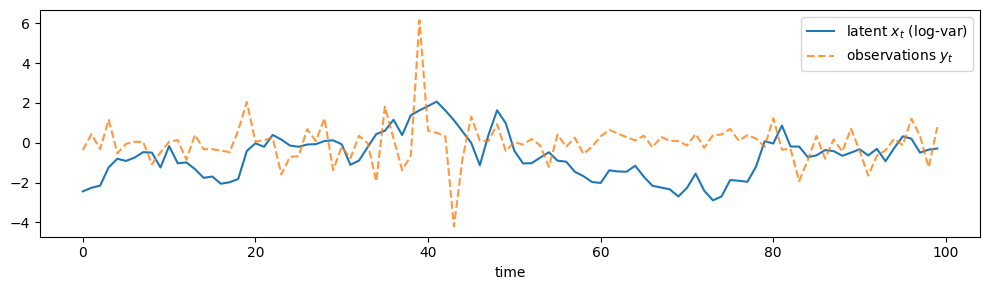

In [17]:
# Extract observations and states for plotting (and for inference below)
print(pred.keys())
obs_values = pred["observations"][0]
states = pred["states"][0]

# Plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(obs_times, states, label="latent $x_t$ (log-var)")
ax.plot(obs_times, obs_values, label="observations $y_t$", alpha=0.8, linestyle="--")
ax.legend()
ax.set_xlabel("time")
plt.tight_layout()
plt.show()

## 2.6 Inference: conditioning on data

To do inference given data, we first construct our data as a `Context` object:

In [18]:
observed_context = Context(observations=Trajectory(times=obs_times, values=obs_values))

We create a `data_conditioned_model` that wraps the base model with:

1. **`with Condition(observed_context)`** - this tells us what data to condition the model on.
3. **`with DiscreteTimeSimulator():`** — this tells us HOW to condition the model on the data. Here, it is the same conditioner setup as for simulation, but now the context provides *values* for the observations, so those sites become observed (not sampled).



In [19]:
def data_conditioned_model():
    with DiscreteTimeSimulator():
        with Condition(observed_context):
            return stochastic_volatility_model()


The result is a standard NumPyro model: we can run **NUTS**, **SVI**, or any other NumPyro inference on it.

In [20]:
from numpyro.infer import MCMC, NUTS

nuts_kernel = NUTS(data_conditioned_model)
mcmc = MCMC(nuts_kernel, num_warmup=200, num_samples=200)
mcmc.run(jr.PRNGKey(1))
posterior_sv = mcmc.get_samples()
print("Posterior phi mean:", float(jnp.mean(posterior_sv["phi"])))
print("True phi:", phi_true)

# What did we infer? The Simulator unrolled the model, so we explicitly sampled latent states:
print(posterior_sv.keys())

sample: 100%|██████████| 400/400 [00:00<00:00, 962.64it/s, 15 steps of size 2.42e-01. acc. prob=0.87] 

Posterior phi mean: 0.9077998399734497
True phi: 0.9
dict_keys(['observations', 'phi', 'states', 'times', 'x_0', 'x_Traced<int32[]>with<DynamicJaxprTrace>'])


### What the Simulator did: unrolling

Using the **Simulator** effectively *unrolled* the model: instead of a single `dsx.sample("f", dynamics)` call, the dynamics were expanded into explicit sample sites `states` ($x_0, x_1, \ldots, x_T$) and `observations` ($y_0, y_1, \ldots, y_T$). Pedagogically, the Simulator does something like:

```python
# Conceptual unrolling (what the Simulator does internally):
x_0 = numpyro.sample("x_0", initial_condition)
y_0 = numpyro.sample("y_0", observation_model(x_0, u_0, t_0))
x_1 = numpyro.sample("x_1", state_evolution(x_0, u_0, t_0, t_1))
y_1 = numpyro.sample("y_1", observation_model(x_1, u_1, t_1))
# ... and so on for each time step
```

So MCMC was inferring **both** the parameter $\phi$ and the full latent state trajectory $x_{0:T}$ explicitly. The printed sample keys include `phi` and `states`, ….

Next, we compare MCMC's state recovery vs the true states generated in the original simulation of the model. Note that this is considered a `smoothing` distribution, but we did not run a typical smoothing algorithm (we will do this in later tutorials, and see its advantages)...here, though, we simply ran MCMC directly on the joint inference problem over `phi` and `states`

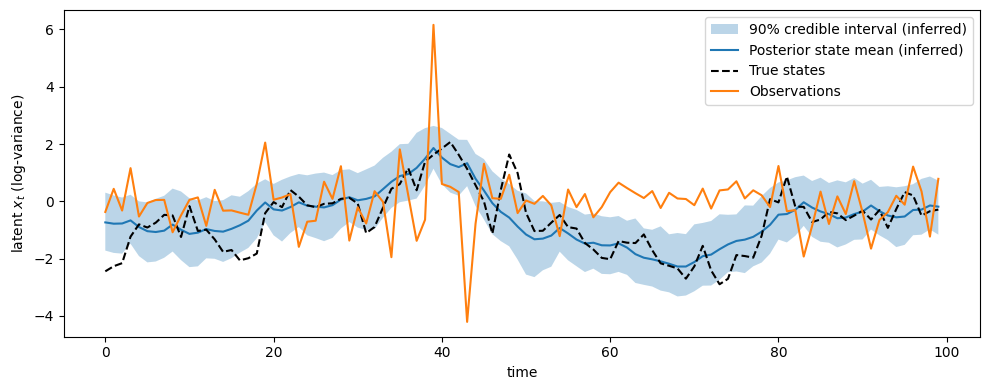

In [21]:
# Plot inferred states vs true states: posterior distribution over the latent trajectory

inferred_states = jnp.asarray(posterior_sv["states"])  # (n_samples, T+1, state_dim)
if inferred_states.ndim == 3:
    inferred_states = inferred_states.squeeze(-1)  # (n_samples, T+1) if state_dim=1

true_states = jnp.asarray(states).flatten()
posterior_mean = inferred_states.mean(axis=0)
q05 = jnp.percentile(inferred_states, 5, axis=0)
q95 = jnp.percentile(inferred_states, 95, axis=0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(obs_times, q05, q95, alpha=0.3, label="90% credible interval (inferred)")
ax.plot(obs_times, posterior_mean, label="Posterior state mean (inferred)", color="C0")
ax.plot(obs_times, true_states, label="True states", color="black", linestyle="--")
ax.plot(obs_times, obs_values, label="Observations", color="C1")
ax.set_xlabel("time")
ax.set_ylabel("latent $x_t$ (log-variance)")
ax.legend()
plt.tight_layout()
plt.show()

### Lead-in to Part 3

Sometimes it is too costly or difficult to infer these latent states explicitly via MCMC/SVI—especially for long time series or complex dynamics. That is where **filtering** comes to the rescue: it allows MCMC/SVI to focus only on **parameters**, while the filter **marginalizes** (averages) over the possible latent states and computes $p(y_{1:T} \mid \theta)$. In Part 3 we will see how to do that.

**Next:** [Part 3 — Filtering and the marginal log-likelihood](../03_filtering_mll.ipynb)